In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [34]:
from sklearn.datasets import fetch_openml

housing = fetch_openml(name="house_prices", as_frame=True)

In [35]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [36]:
housing.DESCR


"Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.\n\nWith 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.\n\nMSSubClass: Identifies the type of dwelling involved in the sale.\t\n\n        20\t1-STORY 1946 & NEWER ALL STYLES\n        30\t1-STORY 1945 & OLDER\n        40\t1-STORY W/FINISHED ATTIC ALL AGES\n        45\t1-1/2 STORY - UNFINISHED ALL AGES\n        50\t1-1/2 STORY FINISHED ALL AGES\n        60\t2-STORY 1946 & NEWER\n        70\t2-STORY 1945 & OLDER\n        75\t2-1/2 STORY ALL AGES\n        80\tSPLIT OR MULTI-LEVEL\n        85\tSPLIT FOYER\n        90\tDUPLEX - ALL STYLES AND AGES\n       120\t1-STORY PUD

In [37]:
df = housing.frame.copy()
df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [38]:
missing_data=df.isnull().sum()
missing_data[missing_data>0]

LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [39]:
str_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
            'BsmtFinType2', 'MasVnrType']
df[str_cols] = df[str_cols].fillna("None")

In [40]:
num_cols = ['GarageYrBlt', 'MasVnrArea']
df[num_cols] = df[num_cols].fillna(0)

In [41]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

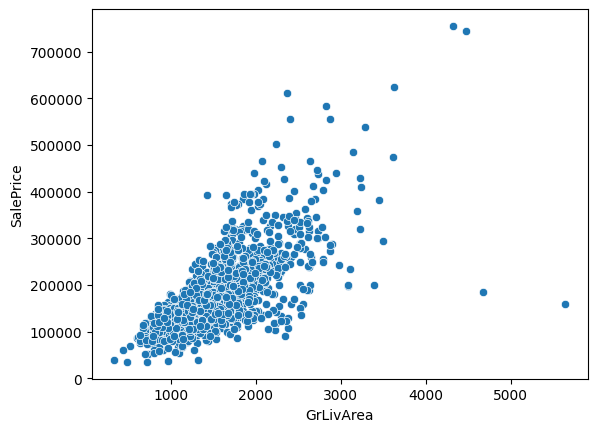

In [43]:
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])


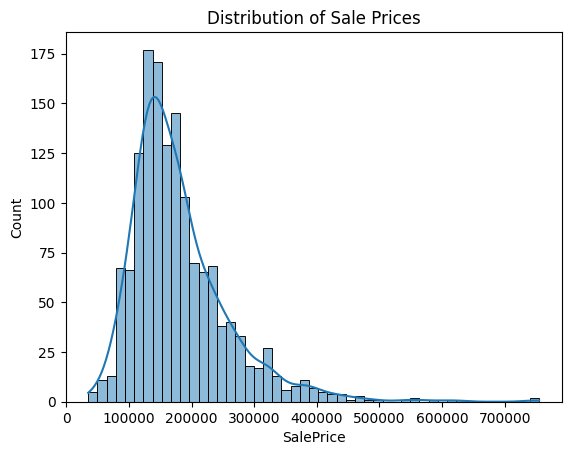

In [44]:
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of Sale Prices')
plt.show()

<Axes: >

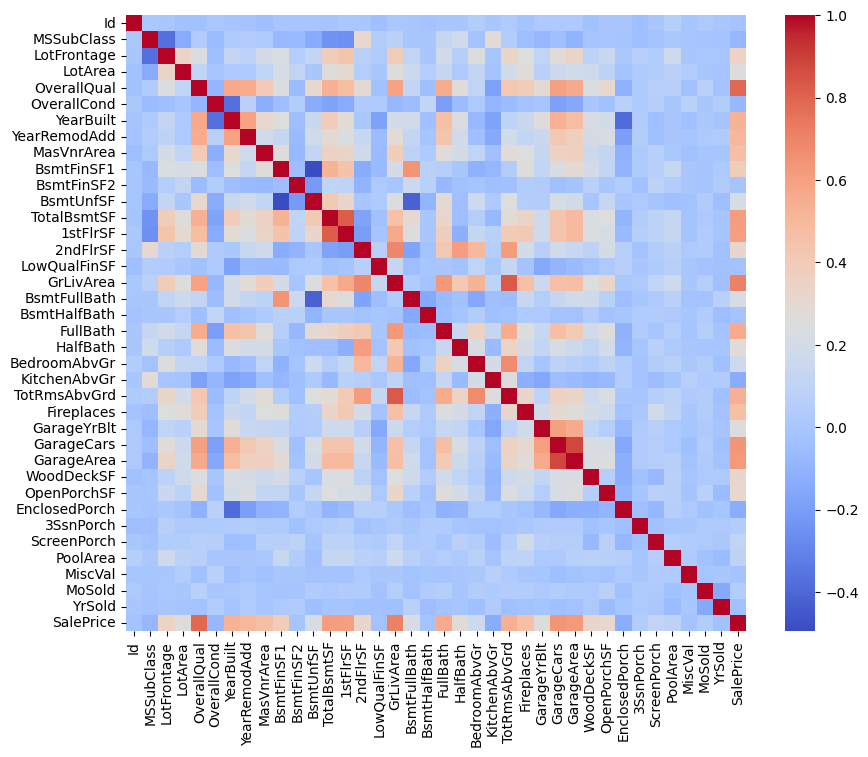

In [45]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")

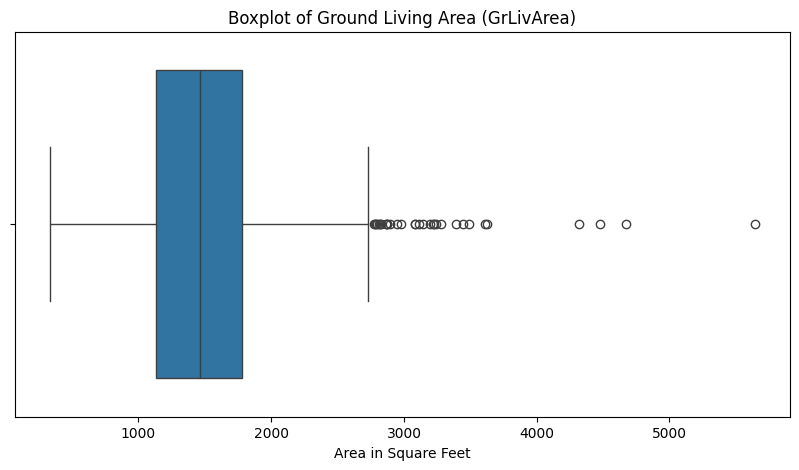

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# رسم Boxplot لمساحة المعيشة
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["GrLivArea"])

plt.title('Boxplot of Ground Living Area (GrLivArea)')
plt.xlabel('Area in Square Feet')
plt.show()

In [47]:
# حذف البيوت التي مساحتها أكبر من 4000 فقط
df = df[df["GrLivArea"] < 4000]

In [48]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

In [49]:
df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

In [50]:
# تحويل نوع السكن لنص (Categorical)
df['MSSubClass'] = df['MSSubClass'].astype(str)

In [51]:
df['SalePrice'] = np.log1p(df['SalePrice'])

In [52]:
# خريطة تحويل الجودة إلى أرقام
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

# قائمة الأعمدة التي تتبع هذا الترتيب
cols_to_map = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
               'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in cols_to_map:
    df[col] = df[col].map(quality_map)

In [53]:
# تحويل باقي الأعمدة النصية تلقائياً
df = pd.get_dummies(df)

In [54]:
from sklearn.model_selection import train_test_split

# X هي الميزات، y هو الهدف (السعر)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# تقسيم البيانات لتدريب واختبار (80% تدريب، 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
print(df.dtypes.value_counts())

bool       230
int64       45
float64      4
Name: count, dtype: int64


In [57]:
print(np.isinf(X_train_scaled).sum())

0


In [58]:
correlations = df.corr()['SalePrice'].sort_values()

# عرض الخصائص ذات الارتباط السلبي
print(correlations[correlations < 0])

HouseAge            -0.589591
GarageFinish_Unf    -0.432224
MasVnrType_None     -0.391148
GarageType_Detchd   -0.389477
CentralAir_N        -0.353707
                       ...   
LandContour_Lvl     -0.011672
HouseStyle_SLvl     -0.010804
Alley_Pave          -0.010804
LotConfig_Corner    -0.006909
MSSubClass_80       -0.000061
Name: SalePrice, Length: 143, dtype: float64


<Axes: xlabel='HouseAge', ylabel='SalePrice'>

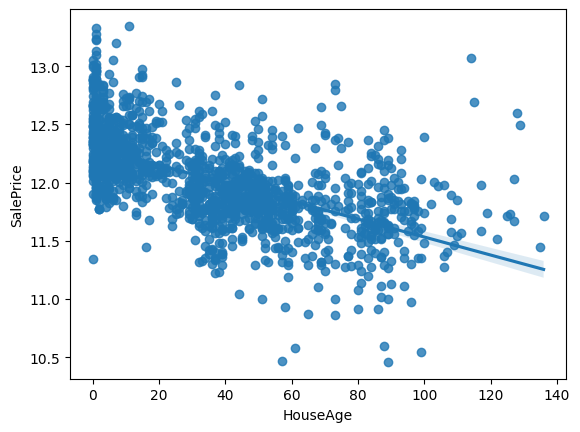

In [59]:
sns.regplot(x='HouseAge',y='SalePrice',data=df)

<Axes: xlabel='GarageArea', ylabel='SalePrice'>

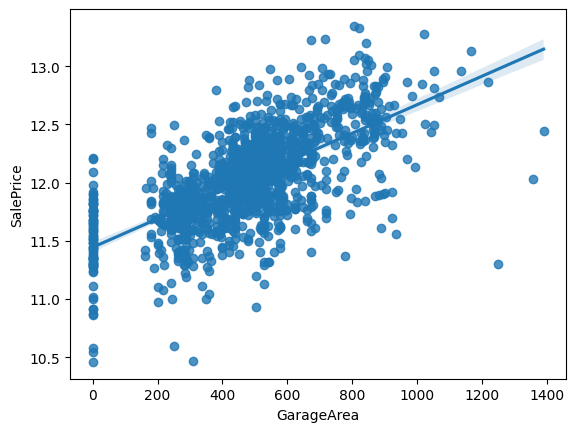

In [60]:
sns.regplot(x='GarageArea',y='SalePrice',data=df)

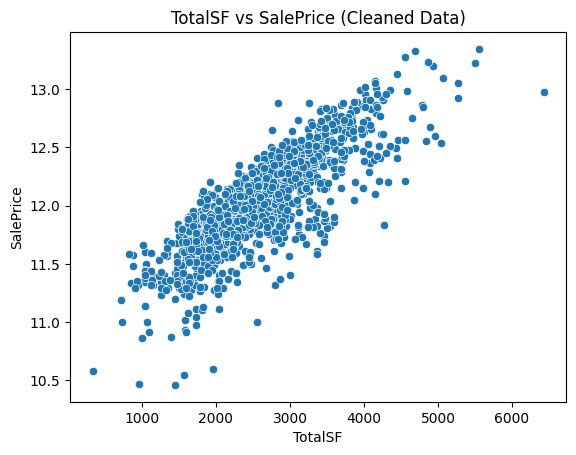

In [61]:
sns.scatterplot(x=df['TotalSF'], y=df['SalePrice'])
plt.title('TotalSF vs SalePrice (Cleaned Data)')
plt.show()

In [62]:
# التأكد من وجود صفوف مكررة بالكامل
duplicate_rows = df.duplicated().sum()
print(f"عدد الصفوف المكررة بالكامل: {duplicate_rows}")

# التأكد من تكرار الـ Id (لو لسه محذفتش عمود الـ Id)
if 'Id' in df.columns:
    duplicate_ids = df['Id'].duplicated().sum()
    print(f"عدد الـ IDs المكررة: {duplicate_ids}")

عدد الصفوف المكررة بالكامل: 0
عدد الـ IDs المكررة: 0


In [63]:
df = df.drop_duplicates()

In [64]:
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

In [65]:
print(df.shape) # تتأكد من عدد الأعمدة والصفوف النهائي
print(df.isnull().values.any()) # تتأكد إنه مفيش ولا قيمة Missing

(1456, 278)
False


In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [67]:
lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

gb = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

In [68]:
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [69]:
lr.coef_

array([-9.96252302e-06,  4.19569713e-04,  2.66106966e-06,  3.59092820e-02,
        3.64432564e-02,  1.79751813e-04,  5.56492828e-04,  6.49218491e-05,
       -1.63529660e-03, -2.61659931e-02,  9.56464950e-03,  8.26770734e-03,
        5.58007760e-05,  9.83547549e-06, -2.26431504e-05,  4.29931212e-05,
        9.59765902e-03,  1.18291889e-05,  9.93912216e-06,  1.29842700e-04,
        1.51610992e-04,  1.78572633e-02, -3.46132675e-03,  2.21597021e-02,
        3.01609850e-02,  1.24825645e-03, -1.75642977e-02,  1.88525734e-02,
        9.48630438e-03,  1.93095798e-02,  4.73863679e-04,  5.77489026e-05,
        1.59388312e-02,  1.05223793e-04,  3.21865578e-02, -1.02675284e-02,
        8.53537733e-05,  1.02471849e-04,  1.55506701e-04,  2.25057985e-04,
        2.61564881e-04,  5.30325822e-04, -5.47581113e-02,  5.96283236e-07,
       -4.03408563e-04, -1.42853753e-03, -1.60828932e-03,  6.47614852e-05,
       -4.03028110e-03, -1.56018210e-01, -6.35818182e-02, -7.01912418e-03,
        7.34858281e-02,  

In [74]:
lr.intercept_

np.float64(11.48260477757897)

In [73]:
import numpy as np

pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_gb = gb.predict(X_test)

final_pred = (pred_lr + pred_rf + pred_gb) / 3



array([12.03334975, 12.03413949, 11.81718459, 11.76206435, 11.33559512,
       11.29646305, 12.32506957, 11.75244827, 11.85782913, 11.83502939,
       11.68397195, 12.80354743, 12.26900543, 12.25218571, 11.24066182,
       11.67829691, 12.18761456, 11.74566309, 12.39751149, 12.27673665,
       11.29527852, 12.37896103, 11.65305824, 11.80004883, 12.2120794 ,
       12.0029207 , 11.56398531, 11.55601471, 11.97604522, 11.80315503,
       11.79787034, 12.13477274, 11.56232304, 11.65645745, 11.76846765,
       12.39479649, 12.5310573 , 11.8858698 , 12.34204015, 11.57762241,
       11.73196298, 12.35598986, 11.9889076 , 11.97872604, 12.68712482,
       12.24198403, 12.12037522, 11.79723017, 11.93905508, 11.67870728,
       11.95027378, 11.71000834, 12.32333866, 11.71235064, 12.15556144,
       12.45849762, 12.18305986, 12.13692853, 11.83036935, 11.95926426,
       11.22893276, 12.70012063, 12.62443991, 11.7036648 , 12.53075024,
       12.23586357, 12.43531985, 12.6832281 , 11.6866633 , 12.05

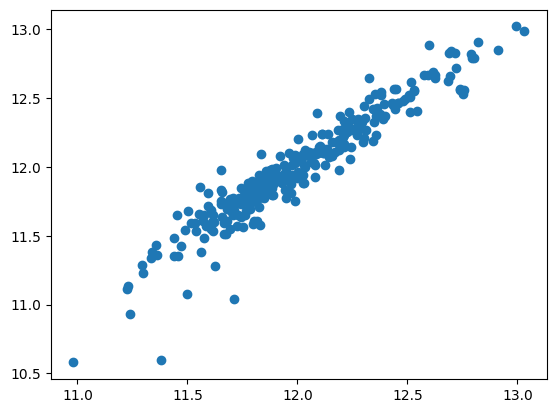

In [78]:
plt.scatter(final_pred,y_test)

In [85]:
residuals=y_test-final_pred
residuals

497     0.089347
1264    0.072118
411     0.067311
1048   -0.109368
1035    0.002989
          ...   
477    -0.062594
675     0.005222
1411   -0.032642
650     0.024478
722     0.078888
Name: SalePrice, Length: 292, dtype: float64

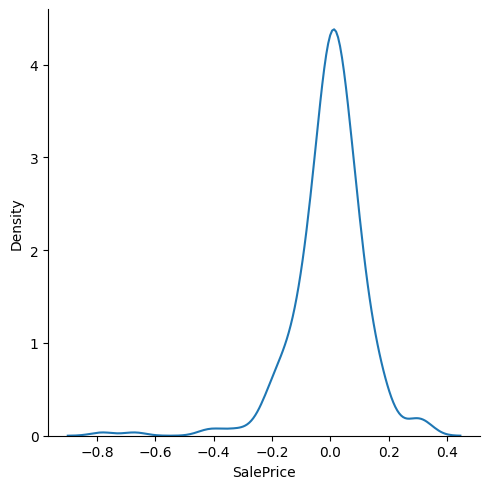

In [86]:
sns.displot(residuals,kind='kde')

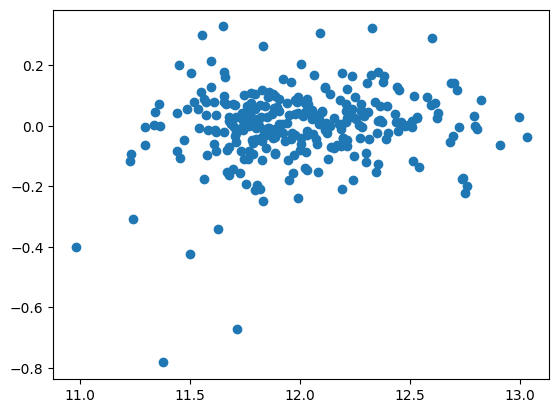

In [87]:
plt.scatter(final_pred,residuals)

(array([  2.,   0.,   0.,   3.,   3.,  25.,  90., 133.,  30.,   6.]),
 array([-0.78208637, -0.67108923, -0.56009209, -0.44909495, -0.33809782,
        -0.22710068, -0.11610354, -0.0051064 ,  0.10589074,  0.21688788,
         0.32788502]),
 <BarContainer object of 10 artists>)

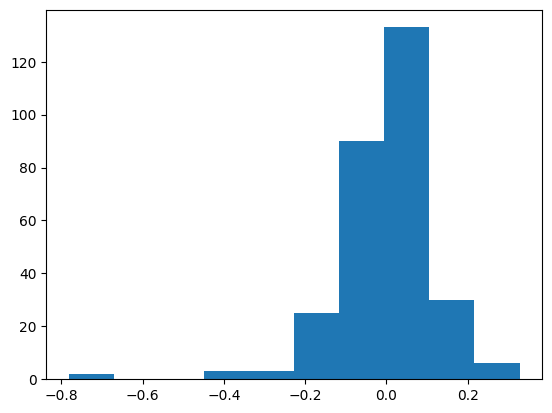

In [88]:
plt.hist(residuals)

In [99]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
score=r2_score(y_test,final_pred)
print("RMSE:", root_mean_squared_error(y_test, final_pred))
print('r2_score',score)

RMSE: 0.12217644406706452
r2_score 0.9054879842317431


In [109]:
#PIKLE THE MODEL FILE FOR DEPLOY MENT


In [110]:
import pickle

In [111]:
pickle.dump(final_pred,open('housing_model.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))